Example 1: lambda=0.01, PMF sum=1.000000000000, minimum PMF value=8.351e-26
Example 2: lambda=0.10, PMF sum=1.000000000000, minimum PMF value=7.420e-19
Example 3: lambda=0.20, PMF sum=1.000000000000, minimum PMF value=3.842e-14
Example 4: lambda=0.30, PMF sum=1.000000000000, minimum PMF value=0.000e+00
Output files were written to: /Users/lusmac/PycharmProjects/PythonProject/Translation/0713/PMF_Bounds
Example     lambda   PMF size            PMF sum        PMF minimum            Stationary distribution
------------------------------------------------------------------------------------------------------
      1       0.01         31     1.000000000000       8.351311e-26           [0.25, 0.25, 0.25, 0.25]
      2       0.10         31     1.000000000000       7.420412e-19           [0.25, 0.25, 0.25, 0.25]
      3       0.20         31     1.000000000000       3.841821e-14           [0.25, 0.25, 0.25, 0.25]
      4       0.30         41     1.000000000000       0.000000e+00           [

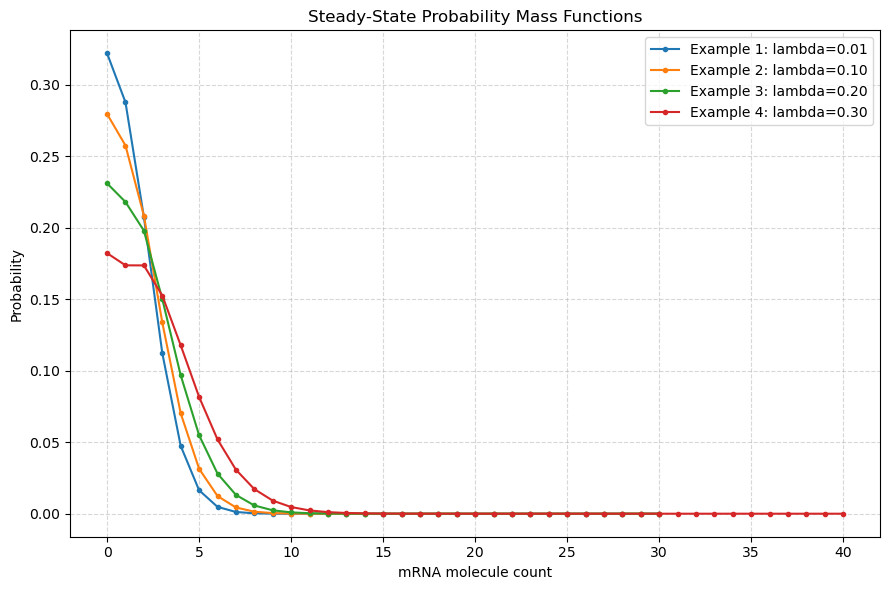

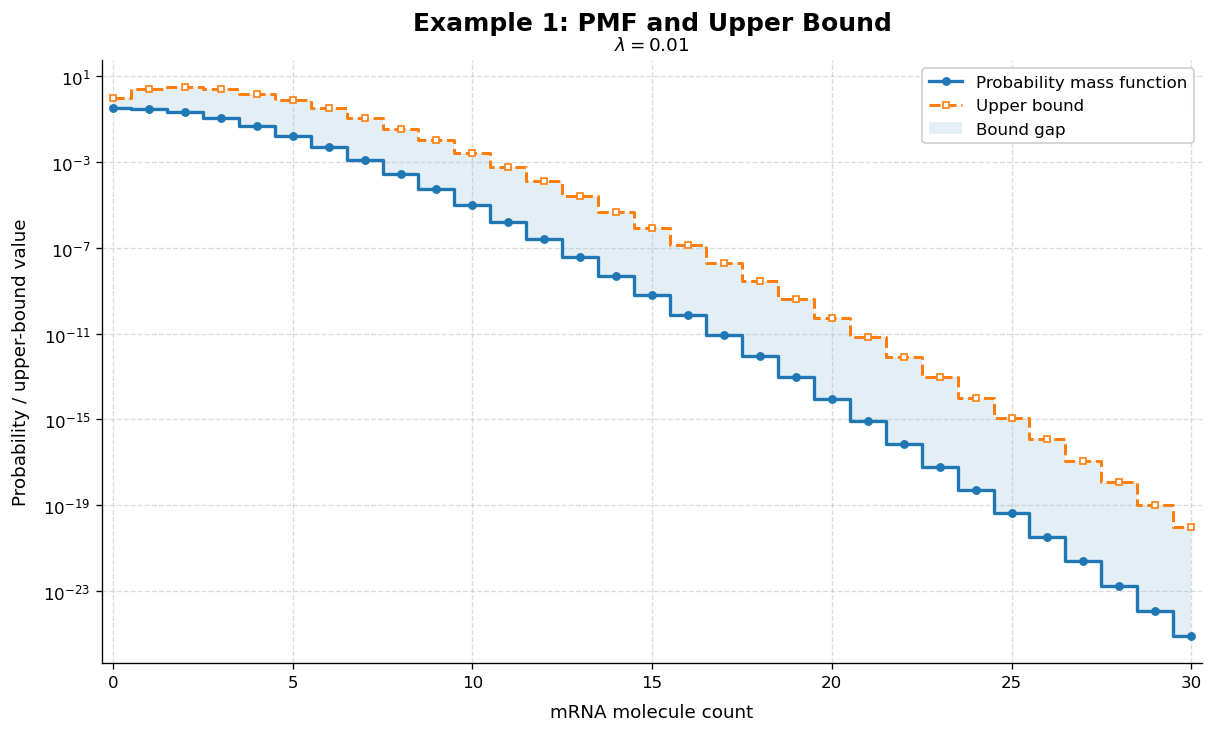

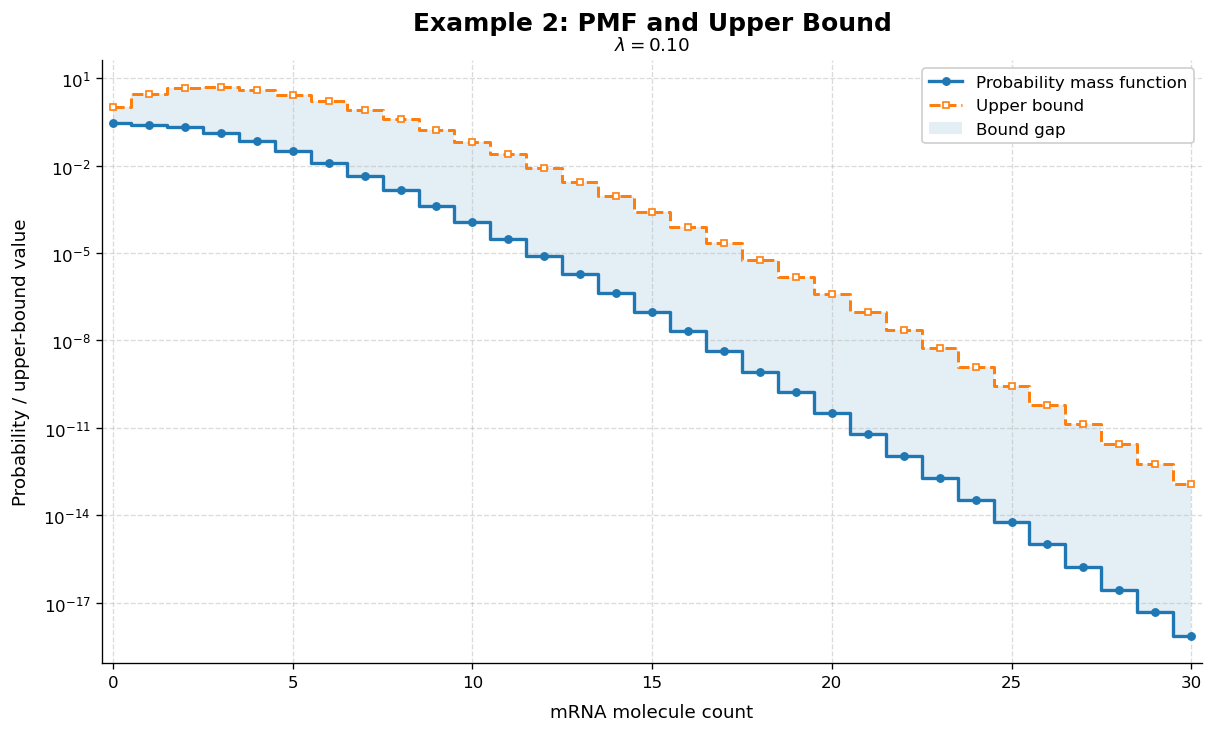

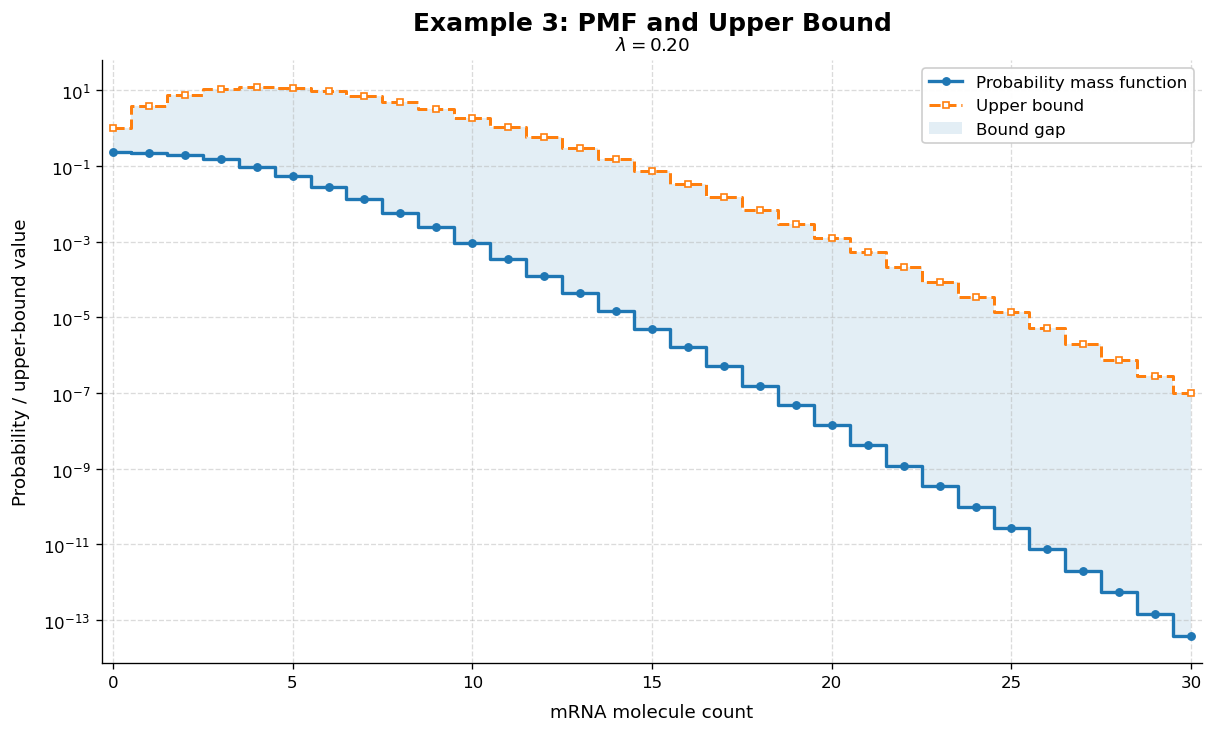

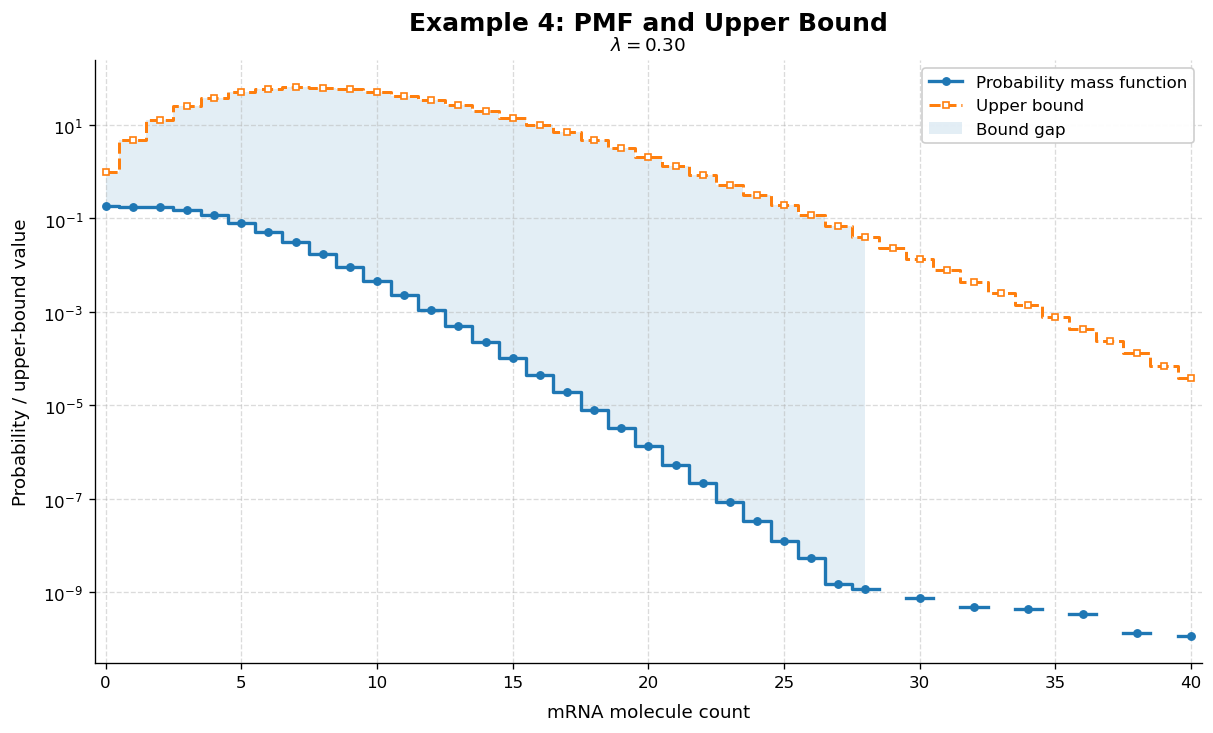

In [2]:
from dataclasses import dataclass
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np

@dataclass(frozen=True)
class ExampleConfig:
    """Parameters that differ between the four examples."""

    index: int
    lam: float
    pmf_size: int
    max_order: int = 200
    delta: float = 1.0
    numerical_tolerance: float = 1e-8


# Shared matrices used by all four examples.
D0 = np.zeros((4, 4), dtype=float)

D1 = np.array(
    [
        [0.2, 0.2, 0.1, 0.8],
        [0.2, 0.2, 0.1, 0.8],
        [0.1, 0.1, 0.1, 0.0],
        [0.8, 0.8, 0.0, 0.8],
    ],
    dtype=float,
)

EXAMPLES = (
    ExampleConfig(index=1, lam=0.01, pmf_size=31),
    ExampleConfig(index=2, lam=0.10, pmf_size=31),
    ExampleConfig(index=3, lam=0.20, pmf_size=31),
    ExampleConfig(index=4, lam=0.30, pmf_size=41),
)

# Set this flag to False when output files are not needed.
SAVE_OUTPUTS = True
OUTPUT_DIRECTORY = Path("PMF_Bounds")

## 3. Model Construction Utilities

def validate_inputs(
    d0: np.ndarray,
    d1: np.ndarray,
    config: ExampleConfig,
) -> None:
    """Validate matrix dimensions and numerical parameters."""

    if d0.ndim != 2 or d0.shape[0] != d0.shape[1]:
        raise ValueError("D0 must be a square matrix.")
    if d1.shape != d0.shape:
        raise ValueError("D1 must have the same shape as D0.")
    if not 0.0 < config.lam < 1.0:
        raise ValueError("lam must satisfy 0 < lam < 1.")
    if config.delta <= 0.0:
        raise ValueError("delta must be positive.")
    if config.max_order < 0:
        raise ValueError("max_order must be non-negative.")
    if config.pmf_size <= 0:
        raise ValueError("pmf_size must be positive.")
    if config.pmf_size > config.max_order + 1:
        raise ValueError("pmf_size cannot exceed max_order + 1.")
    if config.numerical_tolerance <= 0.0:
        raise ValueError("numerical_tolerance must be positive.")


def build_geometric_coefficients(
    d1: np.ndarray,
    lam: float,
    max_order: int,
) -> list:
    """Build C_r for r = 1, ..., max_order using a stable recurrence."""

    coefficients = [None]
    factor = 1.0 / (1.0 - lam) ** 2
    ratio = lam / (1.0 - lam)

    for _ in range(1, max_order + 1):
        coefficients.append(factor * d1)
        factor *= ratio

    return coefficients


def build_generator(
    d0: np.ndarray,
    d1: np.ndarray,
    lam: float,
) -> np.ndarray:
    """Construct the generator matrix and enforce zero row sums."""

    generator = np.array(
        d0 + d1 / (1.0 - lam),
        dtype=float,
        copy=True,
    )
    off_diagonal_sums = generator.sum(axis=1) - np.diag(generator)
    np.fill_diagonal(generator, -off_diagonal_sums)
    return generator


def compute_stationary_distribution(
    generator: np.ndarray,
) -> np.ndarray:
    """Solve pi D = 0 together with the normalization sum(pi) = 1."""

    state_count = generator.shape[0]
    system = generator.T.copy()
    right_hand_side = np.zeros(state_count, dtype=float)

    system[-1, :] = 1.0
    right_hand_side[-1] = 1.0

    stationary = np.linalg.solve(system, right_hand_side)
    return stationary.reshape(1, -1)

def compute_binomial_moments(
    generator: np.ndarray,
    coefficients: list,
    stationary: np.ndarray,
    max_order: int,
    delta: float,
) -> np.ndarray:
    """Compute binomial moments from order 0 through max_order."""

    state_count = generator.shape[0]
    identity = np.eye(state_count)
    ones = np.ones((state_count, 1))

    z_matrices = [identity]
    moments = np.empty(max_order + 1, dtype=float)
    moments[0] = 1.0

    for order in range(1, max_order + 1):
        convolution = np.zeros_like(generator)

        for coefficient_index in range(1, order + 1):
            previous_z = z_matrices[order - coefficient_index]
            convolution += (
                previous_z @ coefficients[coefficient_index]
            )

        system = order * delta * identity - generator

        # Solve Z_order * system = convolution without forming an inverse.
        z_order = np.linalg.solve(
            system.T,
            convolution.T,
        ).T
        z_matrices.append(z_order)

        moments[order] = float(
            (stationary @ z_order @ ones)[0, 0]
        )

    return moments


def compute_bound_sequence(
    length: int,
    lam: float,
    d1_infinity_norm: float,
    delta: float,
) -> np.ndarray:
    """Compute the analytical bound sequence by recurrence."""

    if length <= 0:
        raise ValueError("length must be positive.")

    alpha = d1_infinity_norm / (
        delta * lam * (1.0 - lam)
    )
    ratio = lam / (1.0 - lam)

    bounds = np.empty(length, dtype=float)
    bounds[0] = 1.0

    for order in range(1, length):
        bounds[order] = (
            bounds[order - 1]
            * ratio
            * (alpha + order - 1)
            / order
        )

    return bounds


def scaled_binomial_coefficient(
    n: int,
    k: int,
    scale: float,
) -> float:
    """Compute binomial(n, k) * scale in the logarithmic domain."""

    if not isinstance(n, int) or not isinstance(k, int):
        raise TypeError("n and k must be integers.")
    if n < 0:
        raise ValueError("n must be non-negative.")
    if k < 0 or k > n:
        raise ValueError("k must satisfy 0 <= k <= n.")

    # Small negative values may appear from floating-point roundoff.
    if scale < 0.0 and not math.isclose(
        scale,
        0.0,
        abs_tol=1e-14,
    ):
        raise ValueError(
            f"Expected a non-negative moment, received {scale}."
        )
    if scale <= 0.0:
        return 0.0

    log_value = (
        math.lgamma(n + 1)
        - math.lgamma(k + 1)
        - math.lgamma(n - k + 1)
        + math.log(scale)
    )

    if log_value < math.log(np.finfo(float).tiny):
        return 0.0
    if log_value > math.log(np.finfo(float).max):
        raise OverflowError(
            "The scaled binomial coefficient exceeds float64 range."
        )

    return math.exp(log_value)


def clean_probability_vector(
    probabilities: np.ndarray,
    tolerance: float,
) -> np.ndarray:
    """Remove tiny negative noise and normalize near-unit totals."""

    cleaned = probabilities.copy()

    small_negative_mask = (
        (cleaned < 0.0)
        & (np.abs(cleaned) <= tolerance)
    )
    cleaned[small_negative_mask] = 0.0

    if np.any(cleaned < -tolerance):
        minimum = float(cleaned.min())
        raise ValueError(
            "The PMF contains a negative value beyond the "
            f"numerical tolerance: {minimum}."
        )

    total = float(cleaned.sum())
    if math.isclose(
        total,
        1.0,
        rel_tol=0.0,
        abs_tol=tolerance,
    ):
        cleaned /= total

    return cleaned


def moments_to_pmf(
    moments: np.ndarray,
    pmf_size: int,
    numerical_tolerance: float,
) -> np.ndarray:
    """Recover PMF values from binomial moments using alternating sums."""

    max_order = len(moments) - 1
    probabilities = np.empty(pmf_size, dtype=float)

    for molecule_count in range(pmf_size):
        terms = []
        sign = 1.0

        for order in range(
            molecule_count,
            max_order + 1,
        ):
            term = scaled_binomial_coefficient(
                order,
                molecule_count,
                float(moments[order]),
            )
            terms.append(sign * term)
            sign = -sign

        # math.fsum reduces cancellation error in the alternating series.
        probabilities[molecule_count] = math.fsum(terms)

    return clean_probability_vector(
        probabilities,
        tolerance=numerical_tolerance,
    )

## 5. Reusable Example Pipeline

@dataclass
class ExampleResult:
    """All numerical outputs produced for one parameter configuration."""

    config: ExampleConfig
    generator: np.ndarray
    stationary: np.ndarray
    binomial_moments: np.ndarray
    binomial_bounds: np.ndarray
    pmf: np.ndarray
    pmf_upper_bounds: np.ndarray


def run_example(
    config: ExampleConfig,
    d0: np.ndarray = D0,
    d1: np.ndarray = D1,
) -> ExampleResult:
    """Run the complete computation for one example."""

    validate_inputs(d0, d1, config)

    coefficients = build_geometric_coefficients(
        d1=d1,
        lam=config.lam,
        max_order=config.max_order,
    )
    generator = build_generator(
        d0=d0,
        d1=d1,
        lam=config.lam,
    )
    stationary = compute_stationary_distribution(
        generator
    )

    moments = compute_binomial_moments(
        generator=generator,
        coefficients=coefficients,
        stationary=stationary,
        max_order=config.max_order,
        delta=config.delta,
    )

    d1_infinity_norm = np.linalg.norm(
        d1,
        ord=np.inf,
    )

    binomial_bounds = compute_bound_sequence(
        length=config.max_order + 1,
        lam=config.lam,
        d1_infinity_norm=d1_infinity_norm,
        delta=config.delta,
    )

    pmf = moments_to_pmf(
        moments=moments,
        pmf_size=config.pmf_size,
        numerical_tolerance=config.numerical_tolerance,
    )

    # One additional bound is retained to match the original outputs.
    pmf_upper_bounds = compute_bound_sequence(
        length=config.pmf_size + 1,
        lam=config.lam,
        d1_infinity_norm=d1_infinity_norm,
        delta=config.delta,
    )

    return ExampleResult(
        config=config,
        generator=generator,
        stationary=stationary,
        binomial_moments=moments,
        binomial_bounds=binomial_bounds,
        pmf=pmf,
        pmf_upper_bounds=pmf_upper_bounds,
    )


def save_result(
    result: ExampleResult,
    output_directory: Path = OUTPUT_DIRECTORY,
) -> None:
    """Save compatible .npy files and one compressed archive per example."""

    output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )
    index = result.config.index

    np.save(
        output_directory / f"PMF_real{index}.npy",
        result.pmf,
    )
    np.save(
        output_directory / f"PMF_bound{index}.npy",
        result.pmf_upper_bounds,
    )
    np.save(
        output_directory / f"BM_real{index}.npy",
        result.binomial_moments,
    )
    np.save(
        output_directory / f"BM_bound{index}.npy",
        result.binomial_bounds,
    )

    np.savez_compressed(
        output_directory / f"PMF_example{index}.npz",
        lam=result.config.lam,
        delta=result.config.delta,
        generator=result.generator,
        stationary=result.stationary,
        binomial_moments=result.binomial_moments,
        binomial_bounds=result.binomial_bounds,
        pmf=result.pmf,
        pmf_upper_bounds=result.pmf_upper_bounds,
    )

## 6. Run All Four Examples

results = {}

for config in EXAMPLES:
    result = run_example(config)
    results[config.index] = result

    if SAVE_OUTPUTS:
        save_result(result)

    print(
        f"Example {config.index}: "
        f"lambda={config.lam:.2f}, "
        f"PMF sum={result.pmf.sum():.12f}, "
        f"minimum PMF value={result.pmf.min():.3e}"
    )

if SAVE_OUTPUTS:
    print(
        "Output files were written to: "
        f"{OUTPUT_DIRECTORY.resolve()}"
    )

header = (
    f"{'Example':>7} "
    f"{'lambda':>10} "
    f"{'PMF size':>10} "
    f"{'PMF sum':>18} "
    f"{'PMF minimum':>18} "
    f"{'Stationary distribution':>34}"
)
print(header)
print("-" * len(header))

for index, result in results.items():
    stationary_text = np.array2string(
        result.stationary.ravel(),
        precision=6,
        separator=", ",
    )
    print(
        f"{index:>7d} "
        f"{result.config.lam:>10.2f} "
        f"{result.config.pmf_size:>10d} "
        f"{result.pmf.sum():>18.12f} "
        f"{result.pmf.min():>18.6e} "
        f"{stationary_text:>34}"
    )

## 8. Optional Detailed Output

def print_sequence(
    label: str,
    values: np.ndarray,
    maximum_items: int = None,
) -> None:
    """Print an indexed numerical sequence in scientific notation."""

    item_count = (
        len(values)
        if maximum_items is None
        else min(maximum_items, len(values))
    )
    print(label)

    for index in range(item_count):
        print(
            f"[{index:3d}] = "
            f"{float(values[index]):.6e}"
        )

    if item_count < len(values):
        omitted = len(values) - item_count
        print(
            f"... {omitted} additional values are omitted."
        )


SELECTED_EXAMPLE = 1
selected_result = results[SELECTED_EXAMPLE]

print_sequence(
    "Binomial moments",
    selected_result.binomial_moments,
    maximum_items=15,
)
print()
print_sequence(
    "Binomial moment bounds",
    selected_result.binomial_bounds,
    maximum_items=15,
)
print()
print_sequence(
    "Probability mass function",
    selected_result.pmf,
)
print()
print_sequence(
    "PMF upper bounds",
    selected_result.pmf_upper_bounds,
)

def plot_pmf_comparison(
    result_mapping: dict,
) -> None:
    """Plot all four PMFs on one figure."""

    plt.figure(figsize=(9, 6))

    for index, result in result_mapping.items():
        x_values = np.arange(
            result.config.pmf_size
        )
        plt.plot(
            x_values,
            result.pmf,
            marker="o",
            markersize=3,
            label=(
                f"Example {index}: "
                f"lambda={result.config.lam:.2f}"
            ),
        )

    plt.xlabel("mRNA molecule count")
    plt.ylabel("Probability")
    plt.title(
        "Steady-State Probability Mass Functions"
    )
    plt.grid(
        True,
        linestyle="--",
        alpha=0.5,
    )
    plt.legend()
    plt.tight_layout()
    plt.show()


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter


def plot_pmf_with_bound(
    result: ExampleResult,
) -> None:
    """Plot a PMF and its upper bound on a logarithmic scale."""

    pmf_size = result.config.pmf_size
    x_values = np.arange(pmf_size)

    # Logarithmic axes cannot display non-positive values.
    pmf = np.asarray(result.pmf[:pmf_size], dtype=float)
    upper_bound = np.asarray(
        result.pmf_upper_bounds[:pmf_size],
        dtype=float,
    )

    positive_pmf = np.where(pmf > 0.0, pmf, np.nan)
    positive_bound = np.where(
        upper_bound > 0.0,
        upper_bound,
        np.nan,
    )

    fig, ax = plt.subplots(
        figsize=(10, 6),
        dpi=120,
        constrained_layout=True,
    )

    # PMF: use a step line to emphasize its discrete nature.
    ax.plot(
        x_values,
        positive_pmf,
        drawstyle="steps-mid",
        marker="o",
        markersize=4.5,
        markeredgewidth=0.8,
        linewidth=2.0,
        label="Probability mass function",
        zorder=3,
    )

    # Upper bound.
    ax.plot(
        x_values,
        positive_bound,
        drawstyle="steps-mid",
        marker="s",
        markersize=4,
        markerfacecolor="white",
        markeredgewidth=1.0,
        linewidth=1.8,
        linestyle="--",
        label="Upper bound",
        zorder=2,
    )

    # Highlight the gap between the PMF and its upper bound.
    valid_region = (
        np.isfinite(positive_pmf)
        & np.isfinite(positive_bound)
        & (positive_bound >= positive_pmf)
    )
    ax.fill_between(
        x_values,
        positive_pmf,
        positive_bound,
        where=valid_region,
        step="mid",
        alpha=0.12,
        label="Bound gap",
        zorder=1,
    )

    ax.set_yscale("log")

    ax.set_xlabel(
        "mRNA molecule count",
        fontsize=11,
        labelpad=8,
    )
    ax.set_ylabel(
        "Probability / upper-bound value",
        fontsize=11,
        labelpad=8,
    )

    ax.set_title(
        f"Example {result.config.index}: PMF and Upper Bound",
        fontsize=15,
        fontweight="semibold",
        pad=18,
    )
    ax.text(
        0.5,
        1.01,
        rf"$\lambda = {result.config.lam:.2f}$",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=11,
    )

    # Configure logarithmic major and minor ticks.
    ax.yaxis.set_major_locator(LogLocator(base=10))
    ax.yaxis.set_minor_locator(
        LogLocator(
            base=10,
            subs=np.arange(2, 10) * 0.1,
        )
    )
    ax.yaxis.set_minor_formatter(NullFormatter())

    ax.grid(
        which="major",
        linestyle="--",
        linewidth=0.8,
        alpha=0.45,
    )
    ax.grid(
        which="minor",
        linestyle=":",
        linewidth=0.6,
        alpha=0.25,
    )

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=10,
        direction="out",
    )

    ax.margins(x=0.01)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        loc="best",
        frameon=True,
        framealpha=0.95,
        fontsize=10,
    )

    plt.show()



plot_pmf_comparison(results)

for result in results.values():
    plot_pmf_with_bound(result)